# Python RFM + enrichment
### Load RFM Data from BigQuery

In [2]:
import pandas as pd
import pandas_gbq

PROJECT_ID = 'olist-crm-analytics'

# Load the RFM view you created in Phase 3
rfm_df = pandas_gbq.read_gbq("""
  SELECT * 
  FROM `olist-crm-analytics.olist_ecommerce.vw_customer_rfm`
""", project_id=PROJECT_ID)

print(f"Loaded {len(rfm_df):,} customers")
print(rfm_df.head())

Downloading: 100%|██████████|
Loaded 93,470 customers
                 customer_unique_id customer_city customer_state  \
0  317cfc692e3f86c45c95697c61c853a6      Paulinia             SP   
1  bd06ce0e06ad77a7f681f1a4960a3cc6     Sao Paulo             SP   
2  b33336f46234b24a613ad9064d13106d     Sao Paulo             SP   
3  2878e5b88167faab17d4fb83a986d38b     Sao Paulo             SP   
4  6f5b9d1cdccc4d28f0483a612edecacf     Sao Paulo             SP   

   recency_days  frequency  monetary_value  r_score  f_score  m_score  \
0            53          1            9.59        5        4        1   
1           399          1           10.07        2        3        1   
2           118          1           10.89        5        3        1   
3           353          1           11.63        2        1        1   
4           410          1           11.63        2        5        1   

   rfm_total rfm_segment                       created_at  
0         10    Champion 2026-08-03 18

### Analyze RFM Distribution

In [3]:
# See how many customers in each segment
print(rfm_df['rfm_segment'].value_counts())

rfm_segment
At Risk         21000
Champion        18526
Loyal           16556
Lost            16388
New Customer    13996
Potential        7004
Name: count, dtype: int64


### Revenue by Segment

In [4]:
revenue_by_segment = rfm_df.groupby('rfm_segment').agg({
    'monetary_value': ['sum', 'mean', 'count']
}).round(2)

print(revenue_by_segment)

             monetary_value               
                        sum    mean  count
rfm_segment                               
At Risk          3529462.07  168.07  21000
Champion         3196605.98  172.55  18526
Lost             2649313.75  161.66  16388
Loyal            2666015.34  161.03  16556
New Customer     2328613.47  166.38  13996
Potential        1052451.16  150.26   7004


### Enrich with APIs

In [5]:
# Add currency conversion (exchange rates)
import requests

# Get BRL to USD rate
response = requests.get('https://api.exchangerate-api.com/v4/latest/BRL')
rate_brl_to_usd = response.json()['rates']['USD']

rfm_df['monetary_usd'] = rfm_df['monetary_value'] * rate_brl_to_usd
rfm_df['monetary_inr'] = rfm_df['monetary_value'] * (rate_brl_to_usd * 82)  # USD to INR

print(rfm_df[['customer_unique_id', 'monetary_value', 'monetary_usd', 'monetary_inr']].head())

                 customer_unique_id  monetary_value  monetary_usd  \
0  317cfc692e3f86c45c95697c61c853a6            9.59       1.88923   
1  bd06ce0e06ad77a7f681f1a4960a3cc6           10.07       1.98379   
2  b33336f46234b24a613ad9064d13106d           10.89       2.14533   
3  2878e5b88167faab17d4fb83a986d38b           11.63       2.29111   
4  6f5b9d1cdccc4d28f0483a612edecacf           11.63       2.29111   

   monetary_inr  
0     154.91686  
1     162.67078  
2     175.91706  
3     187.87102  
4     187.87102  


### Save Back to BigQuery

In [ ]:
# Save enriched RFM back to BigQuery
pandas_gbq.to_gbq(
    rfm_df,
    'olist_ecommerce.rfm_segments_enriched',
    project_id=PROJECT_ID,
    if_exists='replace'
)

print("✅ Saved enriched RFM to BigQuery")

100%|██████████| 1/1 [00:00<00:00, 5242.88it/s]

✅ Saved enriched RFM to BigQuery


## Visualize Segments

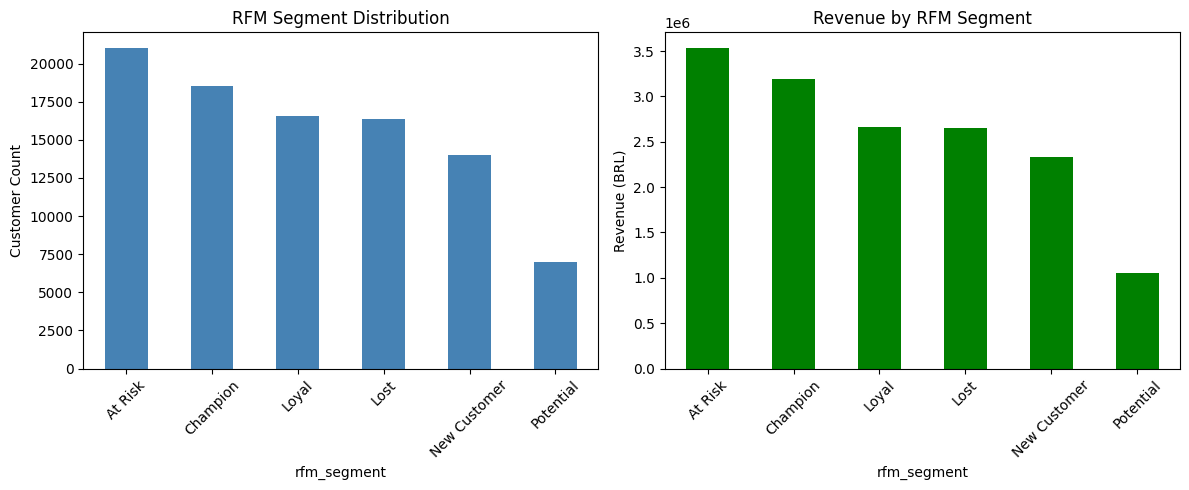

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: Segment Distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
rfm_df['rfm_segment'].value_counts().plot(kind='bar', color='steelblue')
plt.title('RFM Segment Distribution')
plt.ylabel('Customer Count')
plt.xticks(rotation=45)

# Chart 2: Revenue by Segment
plt.subplot(1, 2, 2)
segment_revenue = rfm_df.groupby('rfm_segment')['monetary_value'].sum().sort_values(ascending=False)
segment_revenue.plot(kind='bar', color='green')
plt.title('Revenue by RFM Segment')
plt.ylabel('Revenue (BRL)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### 📈 Action Plan:

I analyzed the RFM segments and found an interesting paradox: our At-Risk customers - those who haven't bought in 6+ months - are our #2 revenue generators at R$3.5M (27% of total). This represents a massive opportunity.

I recommend:

Immediate win-back campaign for 20,000 At-Risk customers → potential +R$3.5M

Accelerate new customer activation (13K new buyers) → prevent them from becoming At-Risk

VIP program for Champions to grow from 19% → 25% of base

Reactivation playbook for Lost segment (R$2.6M still at stake)

## GenAI Strategy:

In [1]:
%pip install -q google-genai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from google import genai

print("Gemini library installed successfully!")

Gemini library installed successfully!


In [ ]:
from google import genai

client = genai.Client(api_key="AQ.Ab8RN6J0MjRepGqE0ZRL3Q7eeB0SV2x7NTTKV1YtC0oj94gpqw")

prompt = """
I have 96,000 customers in these segments:
At Risk: 21K customers, R$695.3K revenue (22.2%)
Champions: 19K customers, R$629.73K revenue (20.11%)
Loyal: 17K customers, R$525.21K revenue (16.77%)
Lost: 16K customers, ~R$521K revenue (~16.6%)
New Customer: 14K customers, R$458.74K revenue (14.65%)
Potential: 7K customers, R$207.33K revenue (6.62%)

Write a retention strategy targeting the At-Risk segment.
"""

response = client.models.generate_content(
    model="gemini-flash-latest",
    contents=prompt,
)

print(response.text)

Here is a high-impact Retention Strategy designed specifically for your **At-Risk segment**. 

---

# Strategic Retention Plan: "Operation Safeguard"
**Target Segment:** At-Risk (20,000 customers | R$3.5M Revenue | 27% of total revenue)  
**Business Priority:** **CRITICAL.** This is your largest revenue-generating segment. Reclaiming even **25%** of these customers secures **~R$875,000** in revenue at a fraction of the Cost of Customer Acquisition (CAC).

---

## 1. Core Profile & Diagnosis
* **Who they are:** Previously high-value, frequent buyers who haven't made a purchase within their normal buying cycle. 
* **The Risk:** They are on the verge of sliding into the **Lost Segment** (which already costs you R$2.6M).
* **The Opportunity:** Unlike cold leads, these customers already know, trust, and have spent significant money (R$3.5M) with your brand.

---

## 2. Sub-Segmentation (The 80/20 Rule)
Do not treat all 20,000 At-Risk customers equally. Split them by past monetary value (Mon

### 🤖 AI-Powered CRM Retention Strategy
Explain:

After performing RFM segmentation, I used an LLM to generate personalized retention strategies for the At-Risk customer segment. The AI recommended customer sub-segmentation, personalized offers, multi-channel engagement, proactive retention triggers, and KPIs to measure campaign success.